# Decision Trees and Random Forest Project — Full Solution

In this notebook we solve the Lending Club loan classification project.

**Goal:** predict whether a borrower is `not.fully.paid`.

We will keep the workflow clean and not overcomplicate it:

1. Load and inspect the data
2. Perform simple EDA
3. Split data into train/test sets
4. Build models using `Pipeline`
5. Use cross validation
6. Evaluate Decision Tree and Random Forest models
7. Compare the results

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Load the Data

In [2]:
loans = pd.read_csv("loan_data.csv")
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


### Basic information

In [3]:
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.2 MB


In [4]:
loans.describe().T

,count,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,0.804970,0.396245,0.000000,1.000000,1.000000,1.000000,1.000000e+00
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01


### Check missing values

This dataset is already clean, but it is always good to check.

In [5]:
loans.isna().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

### Target distribution

Our target column is `not.fully.paid`:

- `0` means the loan was fully paid
- `1` means the loan was not fully paid

In [6]:
loans["not.fully.paid"].value_counts(normalize=True).rename("percentage") * 100

not.fully.paid
0    83.994571
1    16.005429
Name: percentage, dtype: float64

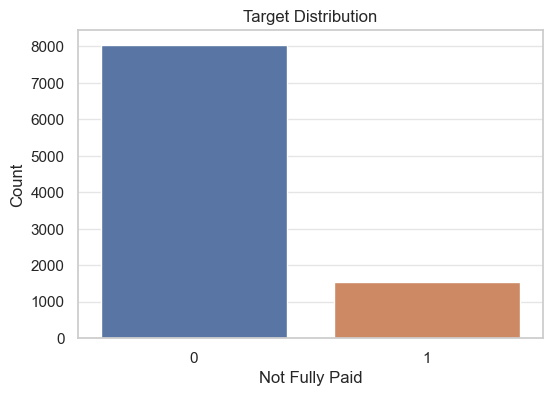

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=loans, x="not.fully.paid", hue="not.fully.paid", legend=False)
plt.title("Target Distribution")
plt.xlabel("Not Fully Paid")
plt.ylabel("Count")
plt.show()

## 3. Exploratory Data Analysis

### Loan purpose count by target

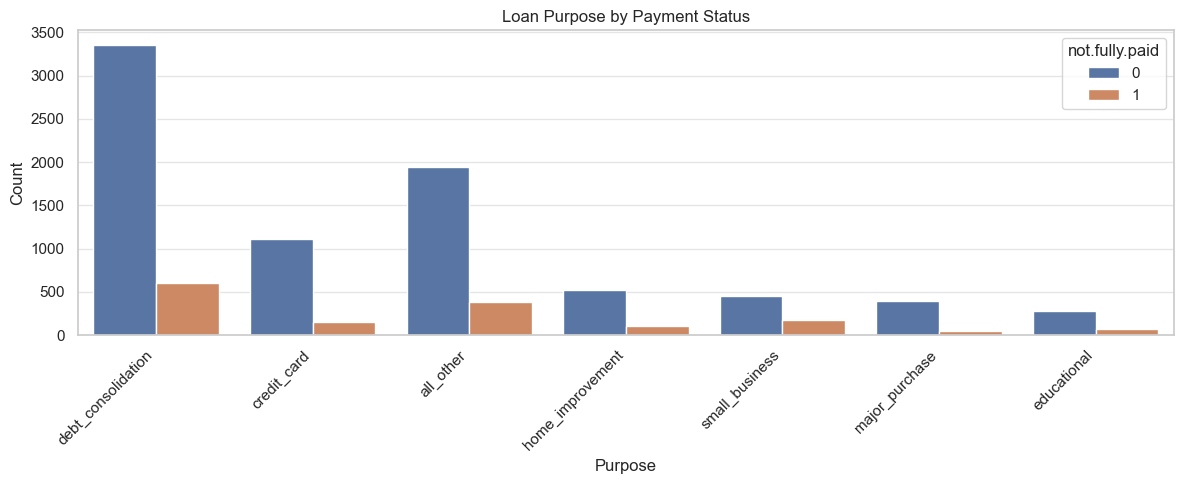

In [8]:
plt.figure(figsize=(12, 5))
sns.countplot(data=loans, x="purpose", hue="not.fully.paid")
plt.title("Loan Purpose by Payment Status")
plt.xlabel("Purpose")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### FICO score vs interest rate

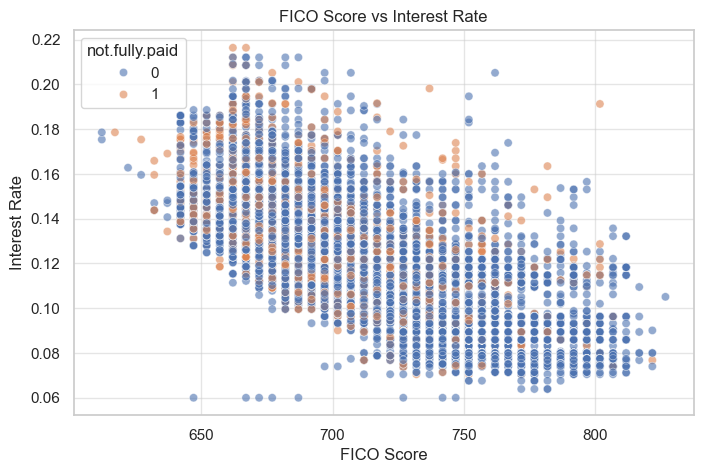

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=loans, x="fico", y="int.rate", hue="not.fully.paid", alpha=0.6)
plt.title("FICO Score vs Interest Rate")
plt.xlabel("FICO Score")
plt.ylabel("Interest Rate")
plt.show()

### Correlation heatmap

Only numeric columns are included in the correlation matrix.

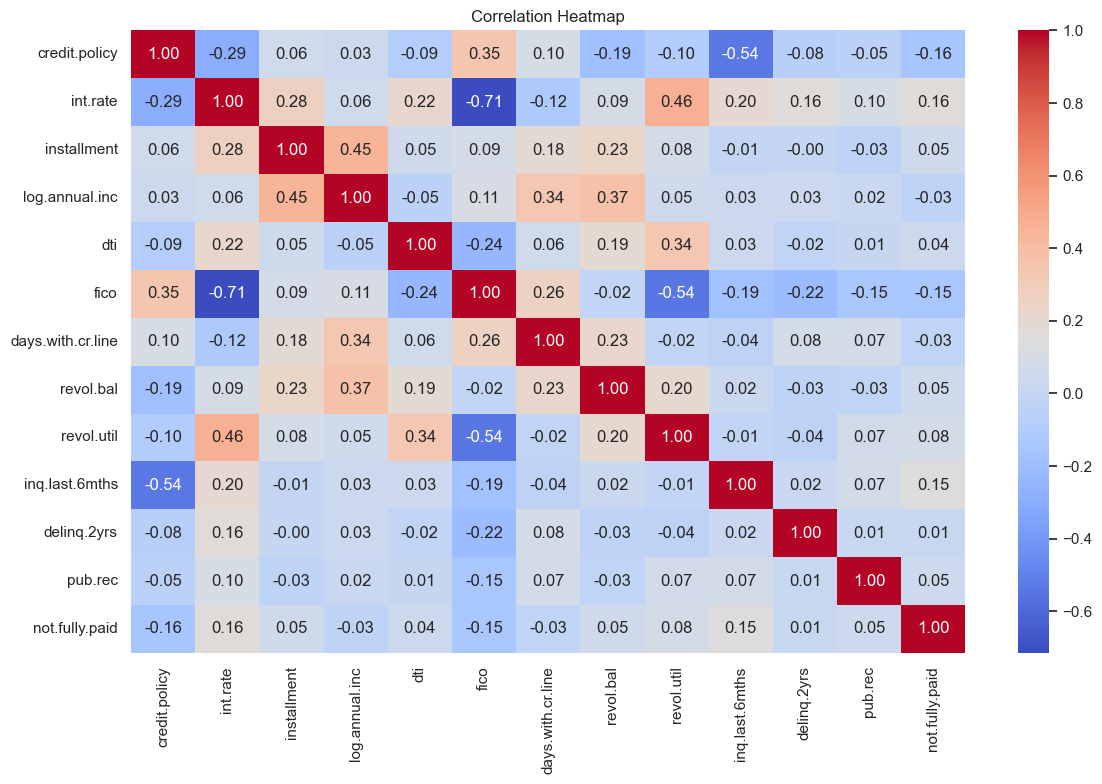

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(loans.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4. Prepare Features and Target

In [11]:
X = loans.drop("not.fully.paid", axis=1)
y = loans["not.fully.paid"]

X.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0


### Identify categorical and numeric columns

The `purpose` column is categorical, so we will encode it inside a pipeline using `OneHotEncoder`.

Using a pipeline is better than manually calling `pd.get_dummies()` because the exact same preprocessing is applied during training, testing, cross validation, and future predictions.

In [12]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['purpose']
Numeric features: ['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']


C:\Users\keds30662\AppData\Local\Temp\ipykernel_31160\2293950454.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


## 5. Train/Test Split

We use `stratify=y` because the classes are imbalanced. This keeps a similar class distribution in both training and testing data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Train target distribution:")
print(y_train.value_counts(normalize=True))
print()
print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (6704, 13)
Testing shape: (2874, 13)
Train target distribution:
not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64

Test target distribution:
not.fully.paid
0    0.839944
1    0.160056
Name: proportion, dtype: float64


## 6. Create Preprocessing Step

For this dataset we only need to encode the categorical column.

Decision Trees and Random Forests do **not** require feature scaling, so we do not use `StandardScaler` here.

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ],
    remainder="passthrough"
)

## 7. Helper Function for Evaluation

In [15]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Print common classification metrics and show a confusion matrix."""
    y_pred = model.predict(X_test)
    
    print(f"{model_name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print()
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()
    
    return y_pred

## 8. Decision Tree Model with Pipeline

In [16]:
decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=6,
        min_samples_leaf=20
    ))
])

decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

### Decision Tree Evaluation on Test Data

Decision Tree Accuracy: 0.8361

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      2414
           1       0.37      0.03      0.06       460

    accuracy                           0.84      2874
   macro avg       0.61      0.51      0.49      2874
weighted avg       0.77      0.84      0.77      2874



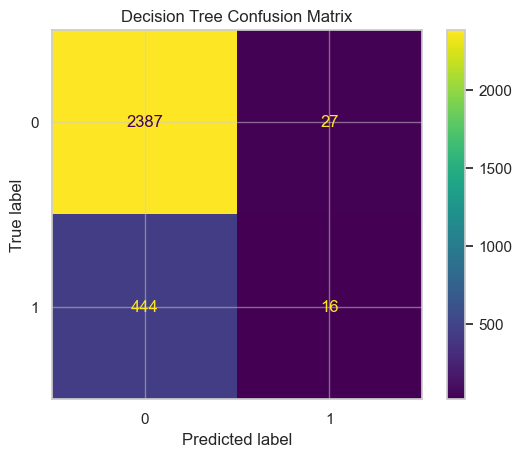

In [17]:
dt_predictions = evaluate_model(
    decision_tree_pipeline,
    X_test,
    y_test,
    model_name="Decision Tree"
)

## 9. Random Forest Model with Pipeline

Random Forest usually performs better than a single Decision Tree because it combines many trees and reduces overfitting.

In [18]:
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=50,
        random_state=RANDOM_STATE,
        max_depth=10,
        min_samples_leaf=10,
        class_weight="balanced",
        n_jobs=1
    ))
])

random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

### Random Forest Evaluation on Test Data

Random Forest Accuracy: 0.7265

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      2414
           1       0.26      0.39      0.32       460

    accuracy                           0.73      2874
   macro avg       0.57      0.59      0.57      2874
weighted avg       0.77      0.73      0.75      2874



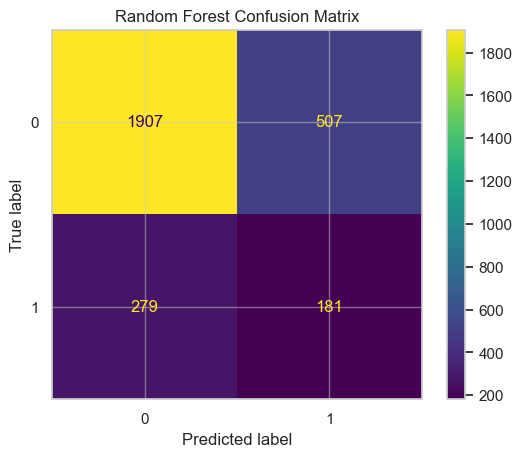

In [19]:
rf_predictions = evaluate_model(
    random_forest_pipeline,
    X_test,
    y_test,
    model_name="Random Forest"
)

## 10. Cross Validation

Cross validation gives us a more reliable estimate of model performance than checking only one train/test split.

We use `StratifiedKFold` because the target classes are imbalanced.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### Cross validation using accuracy

In [21]:
dt_cv_accuracy = cross_val_score(
    decision_tree_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)

rf_cv_accuracy = cross_val_score(
    random_forest_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)

print("Decision Tree CV Accuracy:", dt_cv_accuracy)
print("Decision Tree Mean Accuracy:", dt_cv_accuracy.mean())
print()
print("Random Forest CV Accuracy:", rf_cv_accuracy)
print("Random Forest Mean Accuracy:", rf_cv_accuracy.mean())

Decision Tree CV Accuracy: [0.83141962 0.83194154 0.83663883 0.82715405 0.83185379]
Decision Tree Mean Accuracy: 0.8318015665796346

Random Forest CV Accuracy: [0.72077244 0.71555324 0.73329854 0.71906005 0.73263708]
Random Forest Mean Accuracy: 0.724264269011267


### Cross validation using F1 score

Accuracy can be misleading here because most loans are fully paid. F1 score is useful because it pays more attention to the minority class (`not.fully.paid = 1`).

In [ ]:
dt_cv_f1 = cross_val_score(
    decision_tree_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=1
)

rf_cv_f1 = cross_val_score(
    random_forest_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=1
)

print("Decision Tree CV F1:", dt_cv_f1)
print("Decision Tree Mean F1:", dt_cv_f1.mean())
print()
print("Random Forest CV F1:", rf_cv_f1)
print("Random Forest Mean F1:", rf_cv_f1.mean())

## 11. Feature Importance from Random Forest

Because the model is inside a pipeline, we first get the transformed feature names from the preprocessing step, then read the feature importance values from the trained Random Forest.

In [22]:
trained_preprocessor = random_forest_pipeline.named_steps["preprocessor"]
trained_model = random_forest_pipeline.named_steps["model"]

encoded_cat_features = trained_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = list(encoded_cat_features) + numeric_features

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": trained_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
7,int.rate,0.165610
8,installment,0.098696
9,log.annual.inc,0.096976
14,revol.util,0.090227
12,days.with.cr.line,0.088646
11,fico,0.088506
15,inq.last.6mths,0.087239
13,revol.bal,0.086818
10,dti,0.075664
6,credit.policy,0.058044


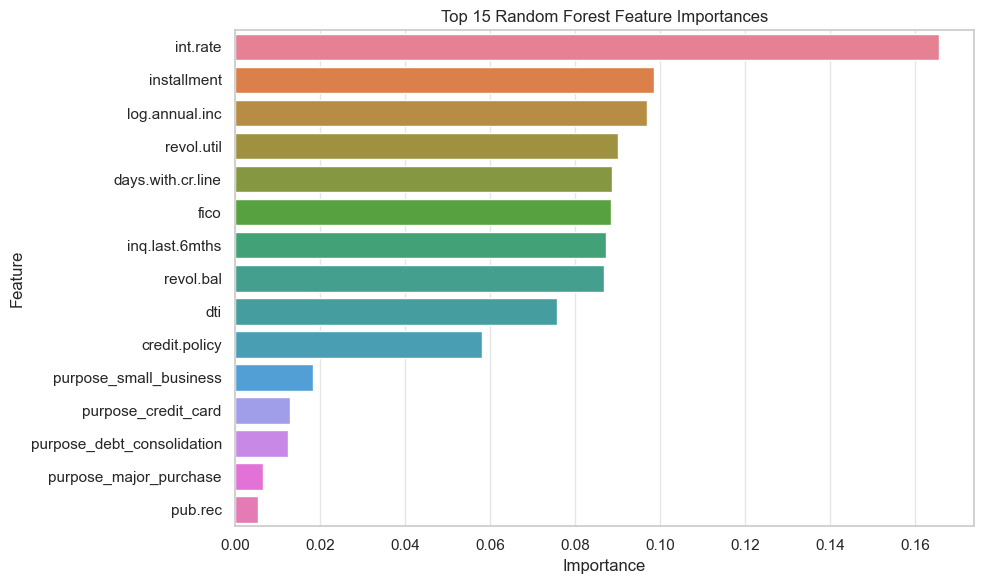

In [23]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature", hue="feature", legend=False)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 12. Compare Models

In [24]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Test Accuracy": [
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "CV Accuracy Mean": [
        dt_cv_accuracy.mean(),
        rf_cv_accuracy.mean()
    ],
    "CV F1 Mean": [
        dt_cv_f1.mean(),
        rf_cv_f1.mean()
    ]
})

results

NameError: name 'dt_cv_f1' is not defined

## 13. Final Conclusion

The **Random Forest** is generally the better model for this project because it combines many decision trees and usually generalizes better than one single tree.

However, this dataset is imbalanced. Because of that:

- Accuracy can look high even when the model struggles with class `1`
- The `classification_report` is very important
- F1 score helps us understand performance on the minority class better

For a simple and clean project solution, the best final model here is the **Random Forest Pipeline**.

## 14. Example: Predict One New Record

This is where the pipeline becomes very useful. We can pass the original unencoded data, including the `purpose` text column, and the pipeline will preprocess it automatically.

In [ ]:
sample = X_test.iloc[[0]]
sample

In [ ]:
prediction = random_forest_pipeline.predict(sample)[0]
prediction_probability = random_forest_pipeline.predict_proba(sample)[0]

print("Prediction:", prediction)
print("Probability for class 0 / fully paid:", prediction_probability[0])
print("Probability for class 1 / not fully paid:", prediction_probability[1])